In [ ]:
!pip install imbalanced-learn xgboost -q
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from google.colab import files
warnings.filterwarnings('ignore')
print("✅ All imports done!")

✅ All imports done!


In [ ]:
print("Upload both cystein_pos_19.txt and cystein_neg_19.txt")
uploaded = files.upload()
pos_file = [k for k in uploaded.keys() if 'pos' in k.lower()][0]
neg_file = [k for k in uploaded.keys() if 'neg' in k.lower()][0]

def parse_file(path, label):
    records = []
    with open(path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                records.append({'Protein_ID': parts[0], 'Position': int(parts[1]),
                              'Window': parts[2], 'Label': label})
    return pd.DataFrame(records)

df_pos = parse_file(pos_file, 1)
df_neg = parse_file(neg_file, 0)
df = pd.concat([df_pos, df_neg], ignore_index=True)
print(f"✅ Loaded: {len(df_pos):,} pos | {len(df_neg):,} neg | Total: {len(df):,}")

Upload both cystein_pos_19.txt and cystein_neg_19.txt


Saving cystein_pos_19.txt to cystein_pos_19 (1).txt
Saving cystein_neg_19.txt to cystein_neg_19.txt
✅ Loaded: 1,870 pos | 9,279 neg | Total: 11,149


In [ ]:
# OPTIMIZED: 39 features
BLOSUM62 = {
    'A':[ 4,-1,-2,-2, 0,-1,-1, 0,-2,-1,-1,-1,-1,-2,-1, 1, 0,-3,-2, 0],
    'R':[-1, 5, 0,-2,-3, 1, 0,-2, 0,-3,-2, 2,-1,-3,-2,-1,-1,-3,-2,-3],
    'N':[-2, 0, 6, 1,-3, 0, 0, 0, 1,-3,-3, 0,-2,-3,-2, 1, 0,-4,-2,-3],
    'D':[-2,-2, 1, 6,-3, 0, 2,-1,-1,-3,-4,-1,-3,-3,-1, 0,-1,-4,-3,-3],
    'C':[ 0,-3,-3,-3, 9,-3,-4,-3,-3,-1,-1,-3,-1,-2,-3,-1,-1,-2,-2,-1],
    'Q':[-1, 1, 0, 0,-3, 5, 2,-2, 0,-3,-2, 1, 0,-3,-1, 0,-1,-2,-1,-2],
    'E':[-1, 0, 0, 2,-4, 2, 5,-2, 0,-3,-3, 1,-2,-3,-1, 0,-1,-3,-2,-2],
    'G':[ 0,-2, 0,-1,-3,-2,-2, 6,-2,-4,-4,-2,-3,-3,-2, 0,-2,-2,-3,-3],
    'H':[-2, 0, 1,-1,-3, 0, 0,-2, 8,-3,-3,-1,-2,-1,-2,-1,-2,-1, 2,-3],
    'I':[-1,-3,-3,-3,-1,-3,-3,-4,-3, 4, 2,-3, 1, 0,-3,-2,-1,-3,-1, 3],
    'L':[-1,-2,-3,-4,-1,-2,-3,-4,-3, 2, 4,-2, 2, 0,-3,-2,-1,-2,-1, 1],
    'K':[-1, 2, 0,-1,-3, 1, 1,-2,-1,-3,-2, 5,-1,-3,-1, 0,-1,-3,-2,-2],
    'M':[-1,-1,-2,-3,-1, 0,-2,-3,-2, 1, 2,-1, 5, 0,-2,-1,-1,-1,-1, 1],
    'F':[-2,-3,-3,-3,-2,-3,-3,-3,-1, 0, 0,-3, 0, 6,-4,-2,-2, 1, 3,-1],
    'P':[-1,-2,-2,-1,-3,-1,-1,-2,-2,-3,-3,-1,-2,-4, 7,-1,-1,-4,-3,-2],
    'S':[ 1,-1, 1, 0,-1, 0, 0, 0,-1,-2,-2, 0,-1,-2,-1, 4, 1,-3,-2,-2],
    'T':[ 0,-1, 0,-1,-1,-1,-1,-2,-2,-1,-1,-1,-1,-2,-1, 1, 5,-2,-2, 0],
    'W':[-3,-3,-4,-4,-2,-2,-3,-2,-2,-3,-2,-3,-1, 1,-4,-3,-2,11, 2,-3],
    'Y':[-2,-2,-2,-3,-2,-1,-2,-3, 2,-1,-1,-2,-1, 3,-3,-2,-2, 2, 7,-1],
    'V':[ 0,-3,-3,-3,-1,-2,-2,-3,-3, 3, 1,-2, 1,-1,-2,-2, 0,-3,-1, 4],
    'X':[ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
}

def encode_opt(window):
    return [sum(BLOSUM62.get(aa, BLOSUM62['X'])) / 20 for aa in window]

X = np.array([encode_opt(w) for w in df['Window']])
y = df['Label'].values
print(f"✅ Features: {X.shape}  (39 optimized features)")

✅ Features: (11149, 39)  (39 optimized features)


In [ ]:
# SMOTE + split
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)
X_tr, X_te, y_tr, y_te = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42)
print(f"✅ Train: {len(X_tr):,} | Test: {len(X_te):,}")

✅ Train: 14,846 | Test: 3,712


In [ ]:
# Fast models
models = {
    'SVM (Linear)': Pipeline([('scaler', StandardScaler()),
                              ('clf', SVC(kernel='linear', C=1, probability=True, random_state=42))]),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                             eval_metric='logloss', random_state=42, n_jobs=-1)
}

print("Training ...")
import time
for name, model in models.items():
    t0 = time.time()
    model.fit(X_tr, y_tr)
    auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    elapsed = time.time() - t0
    print(f"  {name:<18} AUC = {auc:.4f}  ({elapsed:.1f}s)")

Training ...
  SVM (Linear)       AUC = 0.6167  (259.8s)
  Random Forest      AUC = 0.9516  (4.3s)
  XGBoost            AUC = 0.9514  (0.8s)


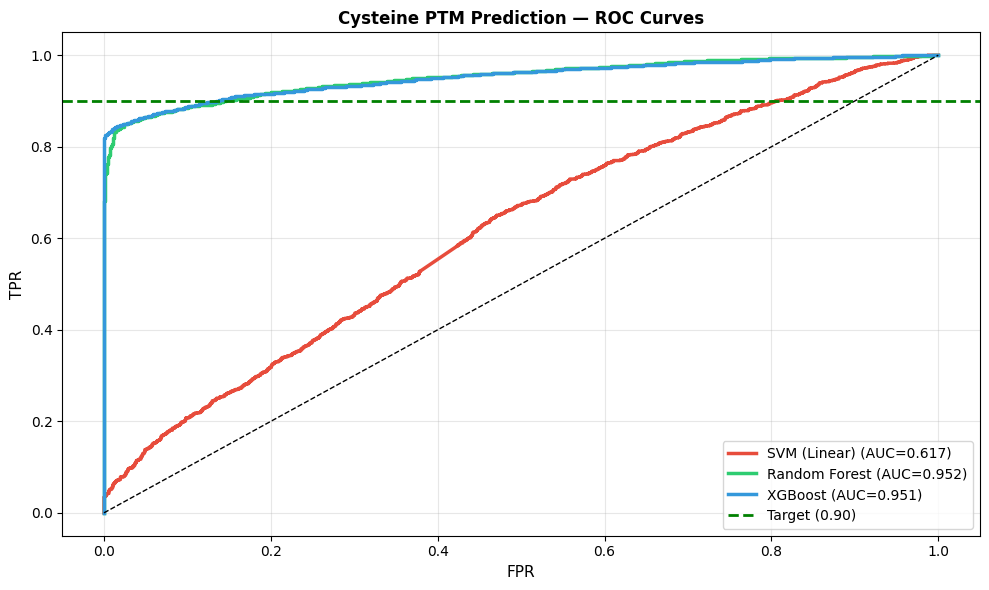

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ROC
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db']
for (name, model), color in zip(models.items(), colors):
    proba = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, proba)
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.axhline(y=0.9, color='green', linestyle='--', lw=2, label='Target (0.90)')
ax.set_xlabel('FPR', fontsize=11); ax.set_ylabel('TPR', fontsize=11)
ax.set_title('Cysteine PTM Prediction — ROC Curves', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cysteine_roc.png', dpi=120, bbox_inches='tight')
plt.show()
files.download('cysteine_roc.png')

In [ ]:
# Results
best_model = models['XGBoost']
y_pred = best_model.predict(X_te)
print("\nClassification Report:")
print(classification_report(y_te, y_pred, target_names=['Unmodified', 'Modified']))


Classification Report:
              precision    recall  f1-score   support

  Unmodified       0.86      0.99      0.92      1879
    Modified       0.99      0.83      0.90      1833

    accuracy                           0.91      3712
   macro avg       0.93      0.91      0.91      3712
weighted avg       0.92      0.91      0.91      3712



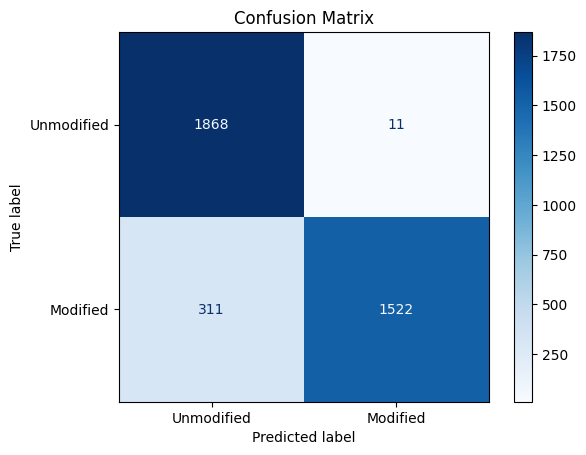

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate and plot the confusion matrix
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unmodified', 'Modified'])

# Plot with a nice blue color map
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()